In [23]:
import numpy as np
from qiskit import qpy
from qiskit.circuit.library import PauliEvolutionGate
import sys
import os

utils_path = os.path.abspath("../lib")

sys.path.append(utils_path)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import matplotlib.pyplot as plt
plt.figure(dpi=300)  # Default is 100
import numpy as np
import qiskit.qpy as qpy
import pickle
import json
import matplotlib.patches as mpatches
from numba import njit
from numba.typed import List
from plotting import *
from readings import *
from tile_process import *
from double_pack import *


<Figure size 1920x1440 with 0 Axes>

In [25]:
def process_placed_tile(placed_tiles_lst, overlap_lst):
    result_tile = []
    for placed_tile in placed_tiles_lst:
        new_tile = placed_tile.copy()
        if placed_tile in overlap_lst or overlap_lst == []:
            new_tile.overlap = True
        else:
            new_tile.overlap = False
        result_tile.append(new_tile)
    return result_tile

def draw_packing_overlap(placed_tiles_lst, bounding_width, bounding_height, seam_lst, intra_color="tomato", inter_color="cyan", new_inter_color = "olive",
                         new_intra_color = "tomato"):
    """Draws the placement of tiles with color and boundaries."""
    fig, ax = plt.subplots(figsize=(10, 6), dpi = 300)
    ax.set_aspect('auto')

    # Define the grid size and spacing between cells
    cell_size = 1  # Define the size of each grid cell (uniform size)

    # Create a colormap for each tile
    colors = plt.cm.get_cmap("tab10", len(placed_tiles_lst))
    # Draw each tile with a unique color and boundary
    for placed_tile in placed_tiles_lst:  # Only unpack two values here
        tile_x, w, h, dx, dy = placed_tile.params()
        overlap = placed_tile.overlap
        if overlap:
            rect = patches.Rectangle((tile_x + dx, dy), w, h, facecolor=new_intra_color)
        else:
            rect = patches.Rectangle((tile_x + dx, dy), w, h, facecolor=intra_color)
        for seam in seam_lst:
            if overlap and dy < seam and dy + h >= seam:
                rect = patches.Rectangle((tile_x + dx, dy), w, h, facecolor=new_inter_color)
            elif dy < seam and dy + h >= seam:
                rect = patches.Rectangle((tile_x + dx, dy), w, h, facecolor=inter_color)
        ax.add_patch(rect)

    # Set limits based on bounding box size
    ax.set_xlim(0, bounding_width)
    ax.set_ylim(0, bounding_height-1)

    # Hide the axis ticks for a cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    for seam in seam_lst:
        plt.axhline(seam - 0.5, color="purple", linewidth=3, linestyle = "--")
    plt.text(0.90, 0.03, rf"$d_c$ = {bounding_width}", ha='right', va='bottom', transform=plt.gcf().transFigure, fontsize = 30)
    plt.show()





In [26]:
# Replace with your .qpy file path
parent_dir = "C:/Users/24835/Desktop/homework/uiuc/Covey/chem/las_uscc_data-main/"
filename = "kremer/6-10/hs/circ_dump.qpy"
# filename = "polyenes/n4/for-plot/circ_dump.qpy"

# filename = "polyenes/n2/for-plot/circ_dump.qpy"
filename = parent_dir + filename
print(filename)
with open(filename, "rb") as f:
    circuits = qpy.load(f)  # loads a list of QuantumCircuit objects

# circuits is a list of QuantumCircuit objects
print(len(circuits))
# print(circuits[0])  # print the first circuit
# print(type(circuits[0]))
circuit = circuits[0].decompose()
# print(circuit)

C:/Users/24835/Desktop/homework/uiuc/Covey/chem/las_uscc_data-main/kremer/6-10/hs/circ_dump.qpy
1


In [27]:
def pauli_diff_positions(p1, p2):
    if len(p1) != len(p2):
        raise ValueError("Pauli strings must have the same length")
    return [i for i, (a, b) in enumerate(zip(p1, p2)) if a != b]

def circuit2excitations(qc):
    n = qc.num_qubits
    excitations = []
    for inst, qargs, cargs in qc.data:
        if isinstance(inst, PauliEvolutionGate):
            op = inst.operator
            paulis = op.paulis
            # if len(paulis) == 2:
            #     print("single hopping")
            # elif len(paulis) == 4:
            #     print("controlled hopping")
            # elif len(paulis) == 8:
            #     print("double hoppings")
            # print(op)
            p = paulis[0]
            x_pos = [i for i, ch in enumerate(p) if str(ch) == "X"]
            y_pos = [i for i, ch in enumerate(p) if str(ch) == "Y"]
            if len(paulis) == 2:
                if len(x_pos) != 1 or len(y_pos) != 1:
                    raise ValueError("Invalid single hopping")
                x = x_pos[0]
                y = y_pos[0]
                a = min([x,y])
                b = max([x,y])
                cur_excitation = [[a], [b]]
            elif len(paulis) == 4:
                if len(x_pos) != 1 or len(y_pos) != 1:
                    raise ValueError("Invalid controlled hopping")
                p1 = paulis[1]
                diff = pauli_diff_positions(p, p1)
                if len(diff) != 1:
                    raise ValueError("Invalid control for controlled hopping")
                diff = diff[0]
                indecies = x_pos + y_pos
                a = min(indecies)
                b = max(indecies)
                cur_excitation = [[a, diff], [b, diff]]
            else:
                indecies = x_pos + y_pos
                if len(indecies) != 4:
                    raise ValueError("Invalid controlled hopping")
                indecies.sort()
                cur_excitation = [[indecies[0], indecies[1]], [indecies[2], indecies[3]]]
            excitations.append(cur_excitation)
    return excitations

excitations = circuit2excitations(circuit)

C:\Users\24835\AppData\Local\Temp\ipykernel_34524\1901600002.py:9: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for inst, qargs, cargs in qc.data:


In [28]:
n = circuit.num_qubits
f_orbs = [2, 2]
f_orbs = [5, 5]
print(excitations)
excitations = orbital_reordering(excitations, f_orbs)
tiles = create_circuit_tile(excitations)
print(excitations)
print(circuit.num_qubits)

[[[0, 1], [4, 9]], [[0, 2], [3, 9]], [[1, 2], [3, 8]], [[1, 3], [4, 7]], [[2, 3], [4, 7]], [[1, 6], [8, 9]], [[2, 3], [6, 8]], [[2, 6], [8, 9]], [[3, 5], [6, 8]], [[3, 5], [6, 8]], [[4, 5], [6, 8]], [[3, 5], [6, 9]], [[0, 3], [7, 9]], [[2, 3], [7, 9]], [[3, 5], [7, 9]], [[3, 5], [7, 8]], [[3, 5], [7, 9]], [[4, 5], [7, 9]], [[4, 6], [7, 9]]]
[[[0, 1], [4, 14]], [[0, 2], [3, 14]], [[1, 2], [3, 13]], [[1, 3], [4, 12]], [[2, 3], [4, 12]], [[1, 11], [13, 14]], [[2, 3], [11, 13]], [[2, 11], [13, 14]], [[3, 10], [11, 13]], [[3, 10], [11, 13]], [[4, 10], [11, 13]], [[3, 10], [11, 14]], [[0, 3], [12, 14]], [[2, 3], [12, 14]], [[3, 10], [12, 14]], [[3, 10], [12, 13]], [[3, 10], [12, 14]], [[4, 10], [12, 14]], [[4, 11], [12, 14]]]
20


In [29]:
filename = "../../test_tiles.txt"
print(len(excitations))
tiles = create_circuit_tile(excitations)
test_tiles = sorted(tiles, key=lambda x: x.w * x.h, reverse=True)
export_tiles_to_file(test_tiles, filename)

19
Tiles successfully exported to ../../test_tiles.txt


In [30]:
separation = 5
seam_lst = [0]
bounding_width, placed_tiles_lst = double_pack_with_c(excitations, separation, seam_lst, if_double=False)


first input has 152 tiles
Tiles successfully exported to ./tiles/inter_intra_tiles.txt
Current Directory: c:\Users\24835\Desktop\homework\uiuc\Covey\chem\H-chain\src\double_packing\lib\tile_packing.exe
sorted
Tiles successfully exported to C:/Users/24835/Desktop/homework/uiuc/Covey/chem/H-chain/test_tiles.txt
Error reading the file: name 'widht' is not defined
first output has 152 tiles
Tiles successfully exported to ./tiles/second_input_tiles.txt
second output has 152 tiles
Current Directory: c:\Users\24835\Desktop\homework\uiuc\Covey\chem\H-chain\src\double_packing\lib\tile_packing.exe
sorted
Tiles successfully exported to C:/Users/24835/Desktop/homework/uiuc/Covey/chem/H-chain/test_tiles.txt
Error reading the file: name 'widht' is not defined
second output has 152 tiles


C:\Users\24835\AppData\Local\Temp\ipykernel_34524\1392929189.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(placed_tiles_lst))


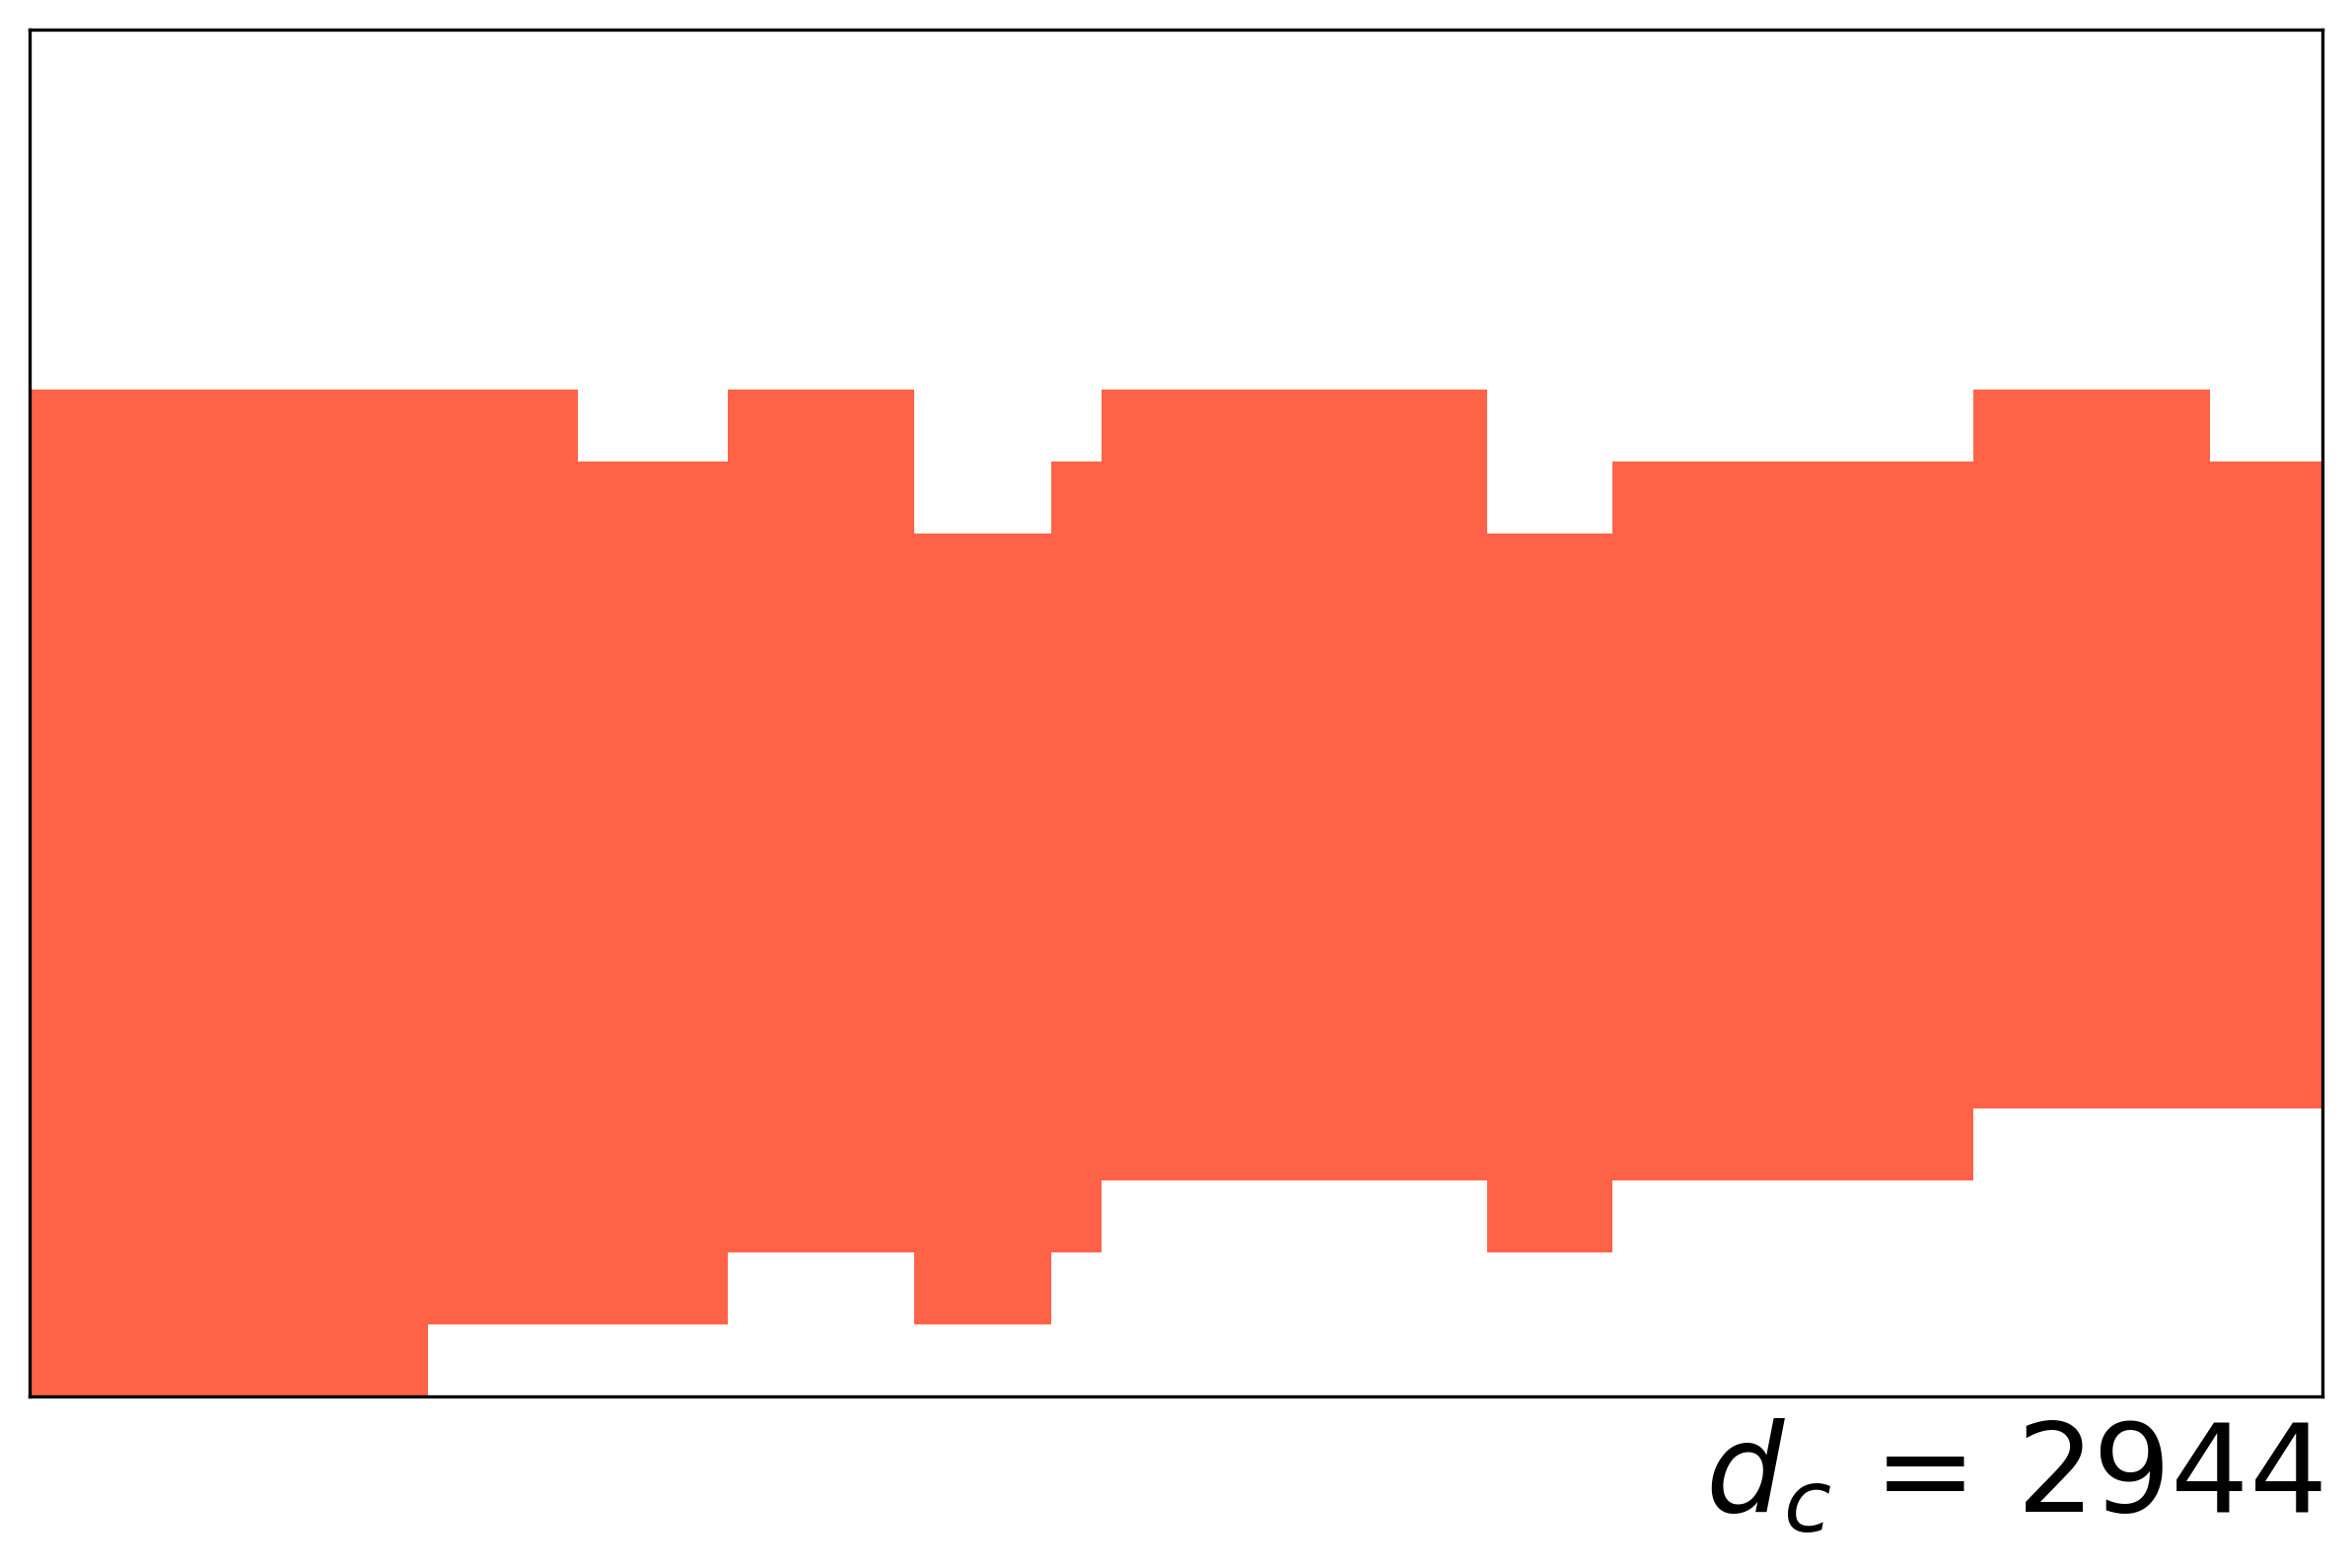

In [31]:
results_tile = process_placed_tile(placed_tiles_lst, [])
draw_packing_overlap(results_tile, bounding_width, n, seam_lst,new_inter_color="blue", new_intra_color="tomato", inter_color="blue")